# **Linear regression**

Marek Šugár

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# ML Stuff
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [15]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **Linear regression**

a.k.a. plain and simple :)

In [ ]:
performance_tracker = {}
performance_mean = {}

for ticker in tickers["Ticker"]:
    Stock_Data = pd.read_sql(f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'", con=StockDataDatabase, parse_dates=["Date"])
    
    Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, left_on="Date", right_on="Date")

    Stock_Data["Target"] = Stock_Data["Close"]
    Stock_Data = Stock_Data.dropna().reset_index(drop=True)

    training_length = 3 # Days
    prediction_length = 1 # Days

    performance_tracker[ticker] = []
    performance_mean[ticker] = []

    MAPEs = []
    AccuracyMean = []
    for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
        if window_start + training_length + prediction_length > len(TrainingDataFrame):
            continue
            
        scaler = StandardScaler()

        Training_Features = scaler.fit_transform(TrainingDataFrame[historic_columns].iloc[window_start:window_start+training_length])
        Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]
    
        Test_Features = scaler.transform(TrainingDataFrame[historic_columns].iloc[window_start+training_length:window_start+training_length+prediction_length])
        Test_Target = Stock_Data["Target"].iloc[window_start+training_length:window_start+training_length+prediction_length]

        MODEL = LinearRegression()

        MODEL.fit(Training_Features, Training_Target)
    
        prediction = MODEL.predict(Test_Features)

        MAPEs.append(100*mean_absolute_percentage_error(Test_Target, prediction))

        which_better = mean_absolute_percentage_error(Test_Target, [Training_Target.iloc[-1]]) >= mean_absolute_percentage_error(Test_Target, prediction)
        AccuracyMean.append(which_better)

        print(ticker, 100*mean_absolute_percentage_error(Test_Target, prediction))
    
    performance_mean[ticker] = AccuracyMean.copy()
    performance_tracker[ticker] = MAPEs.copy()

In [17]:
performance_tracker = pd.DataFrame(performance_tracker).astype("float")

# MEANS & RANGE Metrics
mean_performances = {}
range_performances = {}
for ticker in tickers["Ticker"]:
    mean_performances[ticker] = np.mean(performance_tracker[ticker])
    range_performances[ticker] = np.max(performance_tracker[ticker]) - np.min(performance_tracker[ticker])

mean_performances = dict(sorted(mean_performances.items(), key=lambda x: x[1]))
range_performances = dict(sorted(range_performances.items(), key=lambda x: x[1]))

In [18]:
mean_benchmark = {}
for ticker in tickers["Ticker"]:
    mean_benchmark[ticker] = 100*np.mean(performance_mean[ticker])


mean_benchmark = dict(sorted(mean_benchmark.items(), key=lambda x: x[1]))

In [19]:
np.mean(list(mean_performances.values()))

np.float64(1.8795335282914982)

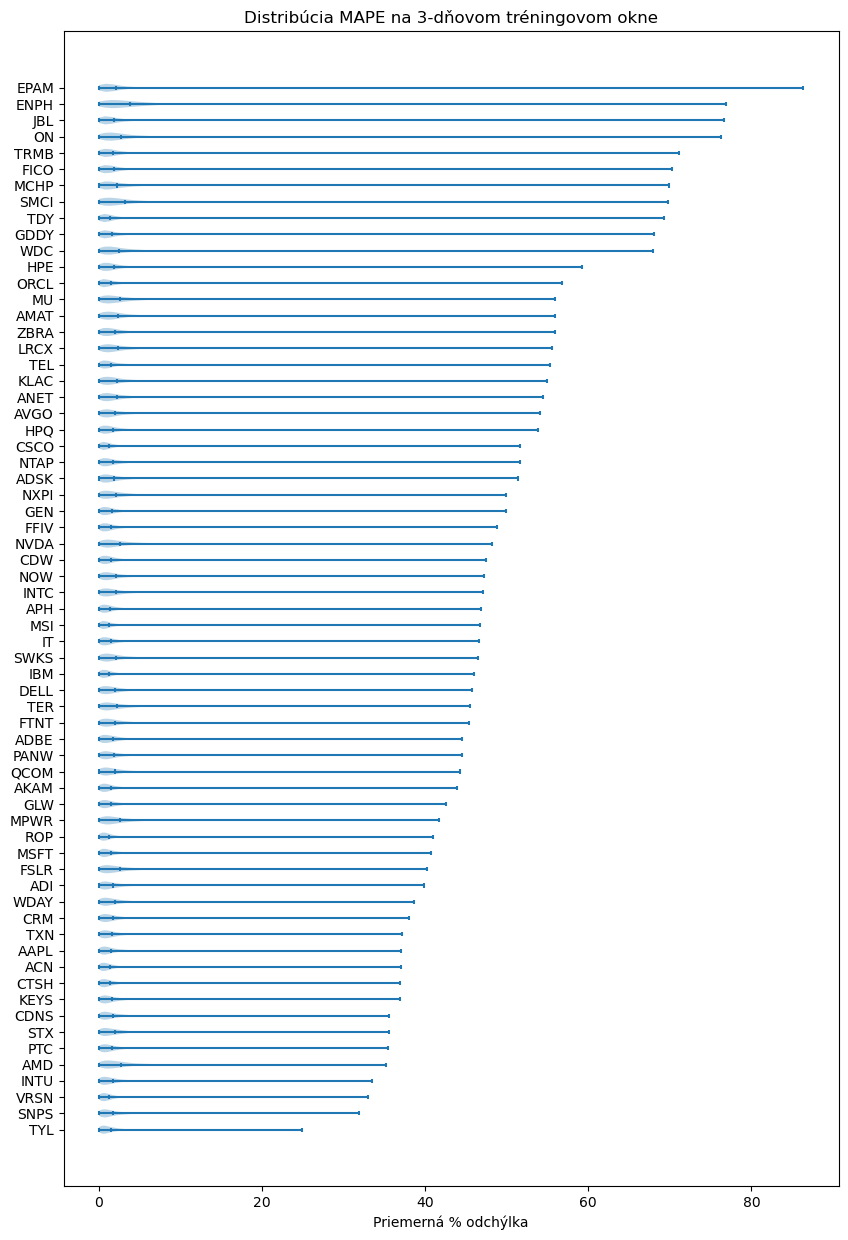

In [20]:
plt.figure(figsize=(10, 15))
plt.violinplot(performance_tracker[list(range_performances.keys())], showmeans=True, orientation="horizontal")

plt.xlabel("Priemerná % odchýlka")
plt.yticks(range(1, 66), list(range_performances.keys()))

plt.title(f"Distribúcia MAPE na {training_length}-dňovom tréningovom okne")

plt.show()

In [21]:
mean_performances

{'ROP': np.float64(1.172854698153958),
 'IBM': np.float64(1.2482137673347906),
 'CSCO': np.float64(1.2683360603074862),
 'MSI': np.float64(1.2691834099176065),
 'VRSN': np.float64(1.2804413085976798),
 'ACN': np.float64(1.3043409336065737),
 'CTSH': np.float64(1.3609347707582813),
 'TDY': np.float64(1.3736021236597773),
 'APH': np.float64(1.3941886133700212),
 'MSFT': np.float64(1.4271899461385649),
 'TYL': np.float64(1.451111786667849),
 'TEL': np.float64(1.4540076434346707),
 'AKAM': np.float64(1.4547586319748278),
 'ORCL': np.float64(1.476326271872921),
 'IT': np.float64(1.480714874874523),
 'FFIV': np.float64(1.490688944292889),
 'CDW': np.float64(1.5184475476204486),
 'GLW': np.float64(1.5287379614481624),
 'AAPL': np.float64(1.529305159494265),
 'GEN': np.float64(1.5401008283924635),
 'KEYS': np.float64(1.608534615939034),
 'TXN': np.float64(1.6163314380563145),
 'GDDY': np.float64(1.6453447672876425),
 'PTC': np.float64(1.6520799256152012),
 'SNPS': np.float64(1.6942062441673522